In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

In [140]:
####### CHECK EMPTY BYPASS #######
conn = sqlite3.connect('../../../databases/bootloader.py_20250921_020716.sqlite')
# conn = sqlite3.connect('../../../databases/bootloader.py_20250921_150047.sqlite')

# chip 5
conn = sqlite3.connect('../../../databases/bootloader.py_20251010_021357.sqlite')

# chip 1
# conn = sqlite3.connect('../../../databases/bootloader.py_20251010_112051.sqlite')

# chip 2
# conn = sqlite3.connect('../../../databases/bootloader.py_20251010_131241.sqlite')

####### RDP BYPASS #######
# chip 1
conn = sqlite3.connect('../../../databases/bootloader.py_20251010_144121.sqlite')

# chip 1
conn = sqlite3.connect('../../../databases/bootloader.py_20251010_171652.sqlite')

In [141]:
df = pd.read_sql("SELECT * FROM experiments", conn)

df['voltage'] = df['voltage'] / 100
df['response'] = df['response'].astype(str)
df['delay'] = (df['delay'] // 4) * 4

df[df['response'] == 'success'].sort_values(by='delay')

,id,voltage,delay,length,color,response
0,1506666,2.08,35624,1896,R,success


In [142]:
df['id'].max().item(), df['id'].count().item()

(1506666, 1)

In [143]:
df['response'].value_counts()

response
success    1
Name: count, dtype: int64

In [144]:
ranges = [
    range(20000, 40000),    
    # range(28450, 28540),
    # range(28970, 29010),
    # range(29240, 29260),
    # range(29400, 29500),
    # range(29465, 29520),  # very good
    # range(29480, 29500),  # very good, tighter
    # range(31950, 32010),
]
ranges_flattened = [item for sublist in ranges for item in sublist]

success_rate = (
    df[
        (df["response"] == "success")
        & (df["delay"].isin(ranges_flattened))
    ].shape[0]
    / df[df["delay"].isin(ranges_flattened)].shape[0]
)
print(f"Success rate where delay in ranges_flattened: {success_rate * 100:.2f}%")


Success rate where delay in ranges_flattened: 100.00%


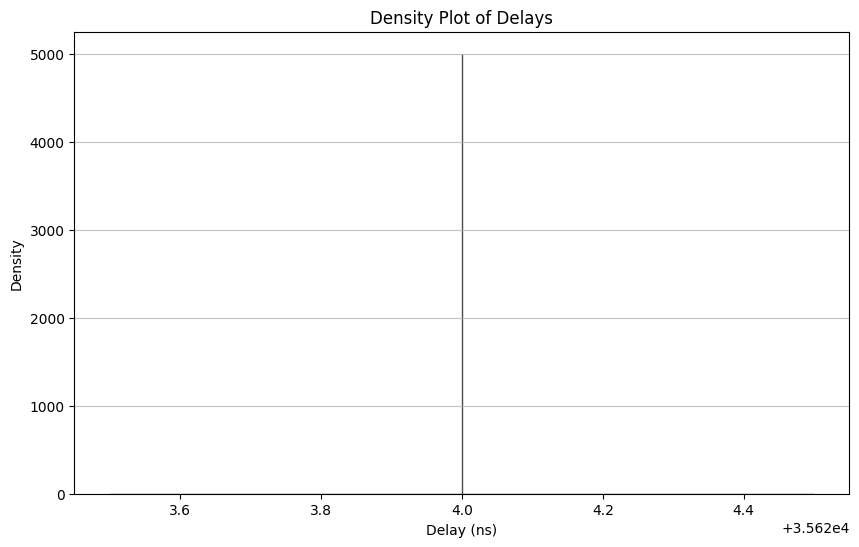

In [145]:
# plot delay as density plot
plt.figure(figsize=(10, 6))
plt.hist(df[
    (df['response'] == 'success')
            #  & (df['delay'] > 29600) & (df['delay'] < 29750)
             ]['delay'], bins=5000, density=True, alpha=0.7,
            color='blue', edgecolor='black')
plt.title('Density Plot of Delays')
plt.xlabel('Delay (ns)')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.75)
# plt.xlim(28000, 34000)
# plt.xticks(np.arange(28000, 34000, 500))
plt.show()

In [146]:
ranges_chip_1 = []  # done at length 1896 and 2.08V

ranges_chip_2 = [] # done at length 1268 and 1.37V

ranges_chip_5 = [  # done at length (250, 2000) and 1.52V
    # check empty glitch? (ld, cp, jpeq)
    (28600, 28750),
    (29100, 29250),
    (29600, 29750),
    # rcf glitch?
    (32100, 32250),
]

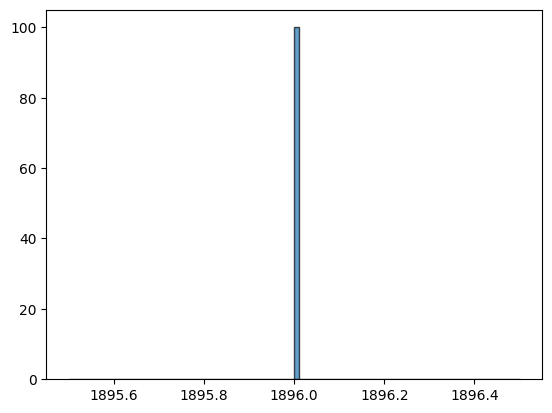

In [147]:
plt.hist(
    df[df["response"] == "success"]["length"],
    density=True,
    bins=100,
    edgecolor="black",
    alpha=0.7,
)
plt.show()